 ### Predicting Delivery Time - Linear Regression 
 
 - Goal: Product Delivery_Time_Days for an order using supply_chain features.
 - Pipeline: data loading > exploration  > preprocessing > modeling > evaluation > interpretation

In [1]:
import pandas as pd
import numpy as np

In [22]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("C:/Users/shala/OneDrive/Desktop/Supply Chain ML Reg Project/supply_chain_dataset_new.csv")

In [33]:
df.head()

,product,product_category,warehouse_dist_km,product_weight_kg,shipment_mode,warehouse_processing_time_days,demand_forecast_unit,shipping_cost,delivery_time_days
0,Laptop,Electronics,1448.36,3.10,Air,2,4516,351.67,4
1,Laptop,Electronics,1130.87,2.57,Air,1,2395,277.57,3
2,Keyboard,Accessories,1523.84,1.77,Road,5,5436,154.78,9
3,Headphones,Accessories,1961.51,1.85,Rail,1,3307,164.32,8
4,Refrigerator,Home Appliances,1082.92,22.45,Air,3,409,1058.46,5


In [34]:
df.shape  # Rows & columns

(1000, 9)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   product                         1000 non-null   str    
 1   product_category                1000 non-null   str    
 2   warehouse_dist_km               1000 non-null   float64
 3   product_weight_kg               1000 non-null   float64
 4   shipment_mode                   1000 non-null   str    
 5   warehouse_processing_time_days  1000 non-null   int64  
 6   demand_forecast_unit            1000 non-null   int64  
 7   shipping_cost                   1000 non-null   float64
 8   delivery_time_days              1000 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 70.4 KB


In [36]:
df.isnull().sum()

product                           0
product_category                  0
warehouse_dist_km                 0
product_weight_kg                 0
shipment_mode                     0
warehouse_processing_time_days    0
demand_forecast_unit              0
shipping_cost                     0
delivery_time_days                0
dtype: int64

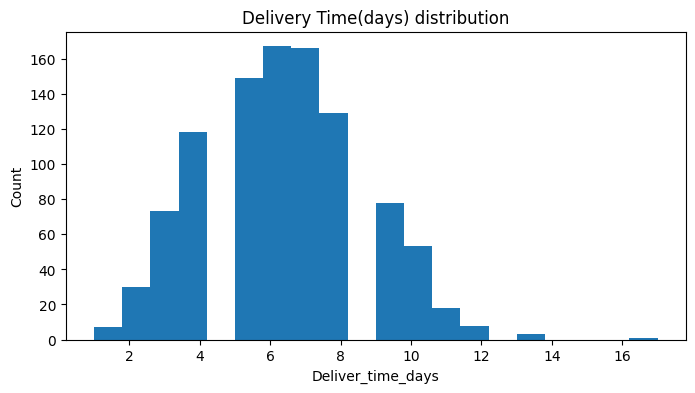

In [37]:
# Histogram of target

plt.figure(figsize=(8,4))
plt.hist(df['delivery_time_days'],bins=20)
plt.title('Delivery Time(days) distribution')
plt.xlabel('Deliver_time_days')
plt.ylabel('Count')
plt.show()

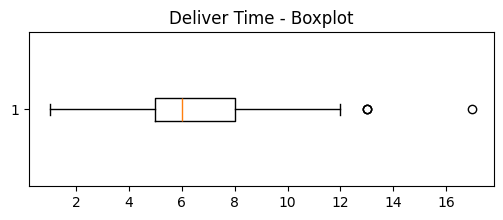

In [38]:
plt.figure(figsize=(6,2))
plt.boxplot(df['delivery_time_days'], vert = False)
plt.title('Deliver Time - Boxplot')
plt.show()

In [39]:
# Check counts for categorical features
print("product_category counts:")
print(df['product_category'].value_counts()) # total numbers
print("\nShipment_mode counts:")
print(df['shipment_mode'].value_counts())

product_category counts:
product_category
Home Appliances    215
Accessories        213
Gadgets            199
Storage            192
Electronics        181
Name: count, dtype: int64

Shipment_mode counts:
shipment_mode
Road    401
Air     360
Rail    217
Sea      22
Name: count, dtype: int64


In [40]:
# Pick features we want to use for initial model
features = [
    'warehouse_dist_km',
    'product_weight_kg',
    'warehouse_processing_time_days',
    'demand_forecast_unit',
    'shipping_cost',
    'shipment_mode',
    'product_category',
    'product'
]

x = df[features].copy()
y = df['delivery_time_days'].copy()

In [41]:
# import only the split tool now
from sklearn.model_selection import train_test_split

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

# 80% for training, 20% for testing

In [42]:
# Show sizes
print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Train rows: 800
Test rows: 200


In [43]:
# We will use one-hot encoding for categorical vars and scale numeric features
# Import transformers only when needed:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define categorical and numeric columns
cat_cols = ['shipment_mode', 'product_category','product']
num_cols = [
     'warehouse_dist_km',
    'product_weight_kg',
    'warehouse_processing_time_days',
    'demand_forecast_unit',
    'shipping_cost'
]

# Build ColumnTransformer:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),  # scale numeric
        ('cat', OneHotEncoder(drop='first',sparse_output=False),cat_cols) # scale categorical
    ],
    remainder='drop' # drop other columns, if present
)

In [45]:

# Fit transformer on training featurs and
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_train_transformed.shape

(800, 27)

In [46]:
# Import LinearRegression only when ready to use
from sklearn.linear_model import LinearRegression

# Create a pipeline : preprocessing -> estimator
model_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('linear_reg',LinearRegression())
])

# Fit the pipeline on training data
model_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [47]:
# Import evaluation metrics when needed
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test set
y_pred = model_pipeline.predict(X_test)

#Calculate metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE:{rmse:.3f}")
print(f"R2:{r2:.3f}")

MAE: 0.385
RMSE:0.519
R2:0.954


In [48]:
df.head(10)

,product,product_category,warehouse_dist_km,product_weight_kg,shipment_mode,warehouse_processing_time_days,demand_forecast_unit,shipping_cost,delivery_time_days
0,Laptop,Electronics,1448.36,3.10,Air,2,4516,351.67,4
1,Laptop,Electronics,1130.87,2.57,Air,1,2395,277.57,3
2,Keyboard,Accessories,1523.84,1.77,Road,5,5436,154.78,9
3,Headphones,Accessories,1961.51,1.85,Rail,1,3307,164.32,8
4,Refrigerator,Home Appliances,1082.92,22.45,Air,3,409,1058.46,5
5,Monitor,Electronics,1082.93,0.84,Rail,5,2583,93.35,9
6,Monitor,Electronics,1989.61,2.38,Rail,4,1822,178.21,11
7,Drone,Gadgets,1583.72,4.20,Road,3,2864,202.44,8
8,Keyboard,Accessories,965.26,0.33,Air,3,2653,196.35,5
9,Keyboard,Accessories,1471.28,1.26,Road,3,3332,147.29,7


In [51]:
# Lets predict delivery time for a new order
# create a single_row Dtaframe just likeour training featurea

new_order = pd.DataFrame({
    'product':['Monitor'],
    'product_category': ['Electronics'],
    'warehouse_dist_km':[1989.62],
    'product_weight_kg':[0.84],
    'shipment_mode':['Rail'],
    'warehouse_processing_time_days':[4],
    'demand_forecast_unit':[1822],
    'shipping_cost':[178.21]
})
# Predict delivery time using our trained pipeline
predicted_days = model_pipeline.predict(new_order)

print(f"Predicted Delivery Time: {predicted_days[0]:.2f} days")

Predicted Delivery Time: 10.60 days
